In [1]:
# --- Part 1: Data Loading and Preparation (Corrected) ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

try:
    df = pd.read_csv("final_preprocessed_dataset.csv")
    print(f"Dataset loaded. Original shape: {df.shape}")
except FileNotFoundError:
    print("ERROR: 'final_preprocessed_dataset.csv' file not found.")
    exit()

original_count = len(df)
df.dropna(subset=['Depression'], inplace=True)
print(f"Removed {original_count - len(df)} rows with missing 'Depression' values.")

X = df.drop('Depression', axis=1)
y = df['Depression']
print("Data loading and preparation complete.")

Dataset loaded. Original shape: (5241, 30)
Removed 1 rows with missing 'Depression' values.
Data loading and preparation complete.


In [2]:
# --- Part 2: Data Splitting and Feature Scaling ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled.")

Data successfully split and scaled.


In [3]:
# --- Part 3: Define Model "Varieties" (Decision Tree) ---
from sklearn.tree import DecisionTreeClassifier

# Api 'max_depth' (tree eke dige) eka wenas karala varieties 3k hadanawa
# Aduma depth eka -> simple model (underfitting wenna puluwan)
# Wadi depth eka -> complex model (overfitting wenna puluwan)
dt_var1 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_var2 = DecisionTreeClassifier(max_depth=7, random_state=42)
dt_var3 = DecisionTreeClassifier(max_depth=None, min_samples_leaf=5, random_state=42) # Depth limit ekak naha, eth leaf eka control karanawa

models = [dt_var1, dt_var2, dt_var3]
model_names = ['Decision Tree (Depth=3)', 'Decision Tree (Depth=7)', 'Decision Tree (Depth=None, MinLeaf=5)']

print("Defined 3 varieties for Decision Tree.")

Defined 3 varieties for Decision Tree.


In [4]:
# --- Part 4: Train and Evaluate All 3 Varieties ---
from sklearn.metrics import classification_report, confusion_matrix, f1_score

results = {}

for model, name in zip(models, model_names):
    print(f"--- Training and Evaluating: {name} ---")

    # 1. Model eka train karanawa
    model.fit(X_train_scaled, y_train)

    # 2. Test data walata predictions hadanawa
    y_pred = model.predict(X_test_scaled)

    # 3. Evaluation Matrix (Classification Report)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Depression', 'Depression']))

    # 4. Evaluation Matrix (Confusion Matrix)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = f1
    print(f"Weighted F1-Score: {f1:.4f}")
    print("---------------------------------------------------\n")

--- Training and Evaluating: Decision Tree (Depth=3) ---

Classification Report:
               precision    recall  f1-score   support

No Depression       0.75      0.81      0.78       663
   Depression       0.85      0.80      0.83       909

     accuracy                           0.80      1572
    macro avg       0.80      0.81      0.80      1572
 weighted avg       0.81      0.80      0.81      1572

Confusion Matrix:
[[538 125]
 [182 727]]
Weighted F1-Score: 0.8056
---------------------------------------------------

--- Training and Evaluating: Decision Tree (Depth=7) ---

Classification Report:
               precision    recall  f1-score   support

No Depression       0.79      0.74      0.77       663
   Depression       0.82      0.86      0.84       909

     accuracy                           0.81      1572
    macro avg       0.81      0.80      0.80      1572
 weighted avg       0.81      0.81      0.81      1572

Confusion Matrix:
[[492 171]
 [129 780]]
Weighted F1

--- Comparison of Member 4's Varieties ---
Decision Tree (Depth=3): 0.8056
Decision Tree (Depth=7): 0.8082
Decision Tree (Depth=None, MinLeaf=5): 0.7852

Conclusion: The best variety for Decision Tree is 'Decision Tree (Depth=7)'.

✅ Individual comparison chart saved to 'member_4_varieties_chart.png'
✅ Text summary saved to 'member_4_results.txt'


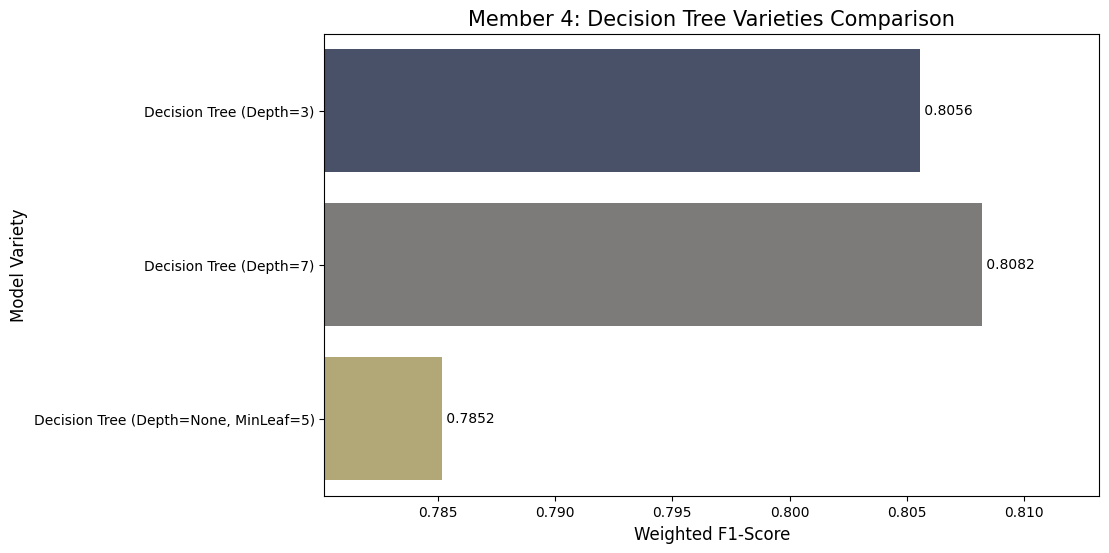

In [5]:
# --- Part 5: Final Conclusion, Save Text & Create Chart (Member 4) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Hondama variety eka hoyanawa
best_model_name = max(results, key=results.get)
best_f1_score = results[best_model_name]

print(f"--- Comparison of Member 4's Varieties ---")
for name, score in results.items():
    print(f"{name}: {score:.4f}")

print(f"\nConclusion: The best variety for Decision Tree is '{best_model_name}'.")

# --- ALUTH KOTASA: INDIVIDUAL GRAPHIC OUTPUT ---

# 2. Chart eka hadanna data prepare karanawa
df_member4 = pd.DataFrame(list(results.items()), columns=['Variety', 'F1-Score'])

# 3. Bar chart eka hadanawa
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Variety', data=df_member4, palette='cividis')
plt.title('Member 4: Decision Tree Varieties Comparison', fontsize=15)
plt.xlabel('Weighted F1-Score', fontsize=12)
plt.ylabel('Model Variety', fontsize=12)
plt.xlim(min(df_member4['F1-Score']) - 0.005, max(df_member4['F1-Score']) + 0.005)

for index, value in enumerate(df_member4['F1-Score']):
    plt.text(value, index, f' {value:.4f}', va='center')

# 4. Chart eka image ekak widiyata save karanawa
chart_filename = "member_4_varieties_chart.png"
plt.savefig(chart_filename)
print(f"\n✅ Individual comparison chart saved to '{chart_filename}'")
# -----------------------------------------------

# 5. Text file eka hadala, eke content eka liyanawa
file_content = f"""
--- MEMBER 4: FINAL OPTIMUM RESULT ---
Model: Decision Tree
Optimum Variety: {best_model_name}
Final Weighted F1-Score for Group Comparison: {best_f1_score:.4f}
--- Details of All Varieties Tested ---
"""
for name, score in results.items():
    file_content += f"{name}: {score:.4f}\n"

text_filename = "member_4_results.txt"
with open(text_filename, 'w') as f:
    f.write(file_content)

print(f"✅ Text summary saved to '{text_filename}'")